## **Week 17 · Day 2 — GAN Fundamentals**

### **Why this matters**

Generative Adversarial Networks (GANs) are the backbone of realistic image generation.
They train two models — a **generator** (creates data) and a **discriminator** (detects fakes) — in a game-like loop that pushes both to improve.

---

### **Theory Essentials**

* **Generator G(z):** maps random noise *z* → synthetic data *x̂* that looks real.
* **Discriminator D(x):** predicts whether *x* is real (1) or fake (0).
* **Adversarial objective:**
  [
  \min_G \max_D ; \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]
  ]
* **Training instability:** if one wins too fast, the other stops learning.
* **Key tricks:** balanced updates, label smoothing, batch norm, LeakyReLU.



### 🧠 Why GANs matter — the big idea

Up until now (Day 1), your generative model learned “**P(x)**”: the distribution of your data — but in a *passive* way (e.g., fitting an MLP to imitate data).
That works only for simple shapes like your ring.
But for **real data** — faces, music, landscapes — the distribution is so complex that a single model can’t easily learn it directly.

GANs solve this by turning generation into a **game between two networks**:

* A **Generator (G)** tries to **create fake data** that looks real.
* A **Discriminator (D)** tries to **tell real from fake**.

Both improve through competition — exactly like two players getting better by challenging each other.
The result: a generator that becomes incredibly good at **mimicking the true data distribution**.

---

### 🎮 The flow of a GAN

Here’s what happens in one training loop:

1. **Start with noise**

   * Sample random latent vectors ( z \sim N(0, I) ).

2. **Generate fake data**

   * Pass ( z ) into the **generator G(z)** → produces a fake sample ( \hat{x} ).

3. **Show both to the discriminator**

   * Give D both **real data (x)** and **fake data (G(z))**.
   * D outputs a probability: real = 1, fake = 0.

4. **Train discriminator (D)**

   * Encourage D to assign 1 to real samples and 0 to fakes.
   * This is just a binary classifier.

5. **Train generator (G)**

   * Now *freeze D* and update G to **fool** D — make ( D(G(z)) ) as close to 1 as possible.
   * In other words, G learns to produce more realistic fakes.

6. **Repeat**

   * Over thousands of rounds, D gets sharper, and G gets more creative.
   * Eventually, G’s fakes are so good that D can’t tell them apart from reals (50/50 chance).

---

### 💥 Why it’s revolutionary

* It made possible **photo-realistic image generation** (faces, art, videos).
* GANs introduced the concept of **adversarial training**, which inspired later models like diffusion and reinforcement adversarial setups.
* They produce data that looks real — not just statistically correct.

---

### 🧩 Intuition summary

| Role                  | Learns                                                  | Analogy                                              |
| --------------------- | ------------------------------------------------------- | ---------------------------------------------------- |
| **Generator (G)**     | How to *create* data that fools the critic              | A counterfeiter making fake money                    |
| **Discriminator (D)** | How to *detect* fakes                                   | A detective identifying counterfeits                 |
| **Training process**  | A zero-sum game — if one improves, the other must adapt | The counterfeiter and the detective improve together |



Epoch 1: Loss_D=0.049, Loss_G=4.386
Epoch 2: Loss_D=1.137, Loss_G=2.322
Epoch 3: Loss_D=1.819, Loss_G=1.552
Epoch 4: Loss_D=1.271, Loss_G=3.299
Epoch 5: Loss_D=0.825, Loss_G=2.284
Epoch 6: Loss_D=0.576, Loss_G=2.636
Epoch 7: Loss_D=0.880, Loss_G=1.910
Epoch 8: Loss_D=0.948, Loss_G=1.531
Epoch 9: Loss_D=0.888, Loss_G=1.800
Epoch 10: Loss_D=0.579, Loss_G=2.004


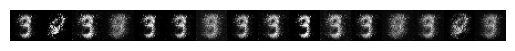

In [2]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
torch.manual_seed(42)

# Data (MNIST 0–1 normalized)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# Generator & Discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G, D = Generator(), Discriminator()
loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Training loop
for epoch in range(10):
    for real, _ in loader:
        bsz = real.size(0)
        real = real
        z = torch.randn(bsz, 100)
        fake = G(z)

        # --- Train Discriminator ---
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_D = -(torch.log(D_real + 1e-8).mean() + torch.log(1 - D_fake + 1e-8).mean())
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train Generator ---
        D_fake = D(fake)
        loss_G = -torch.log(D_fake + 1e-8).mean()
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    print(f"Epoch {epoch+1}: Loss_D={loss_D:.3f}, Loss_G={loss_G:.3f}")

# Generate samples
with torch.no_grad():
    z = torch.randn(16, 100)
    gen = (G(z) + 1) / 2
    grid = torch.cat([g.squeeze() for g in gen], dim=1)
plt.imshow(grid, cmap="gray"); plt.axis("off"); plt.show()


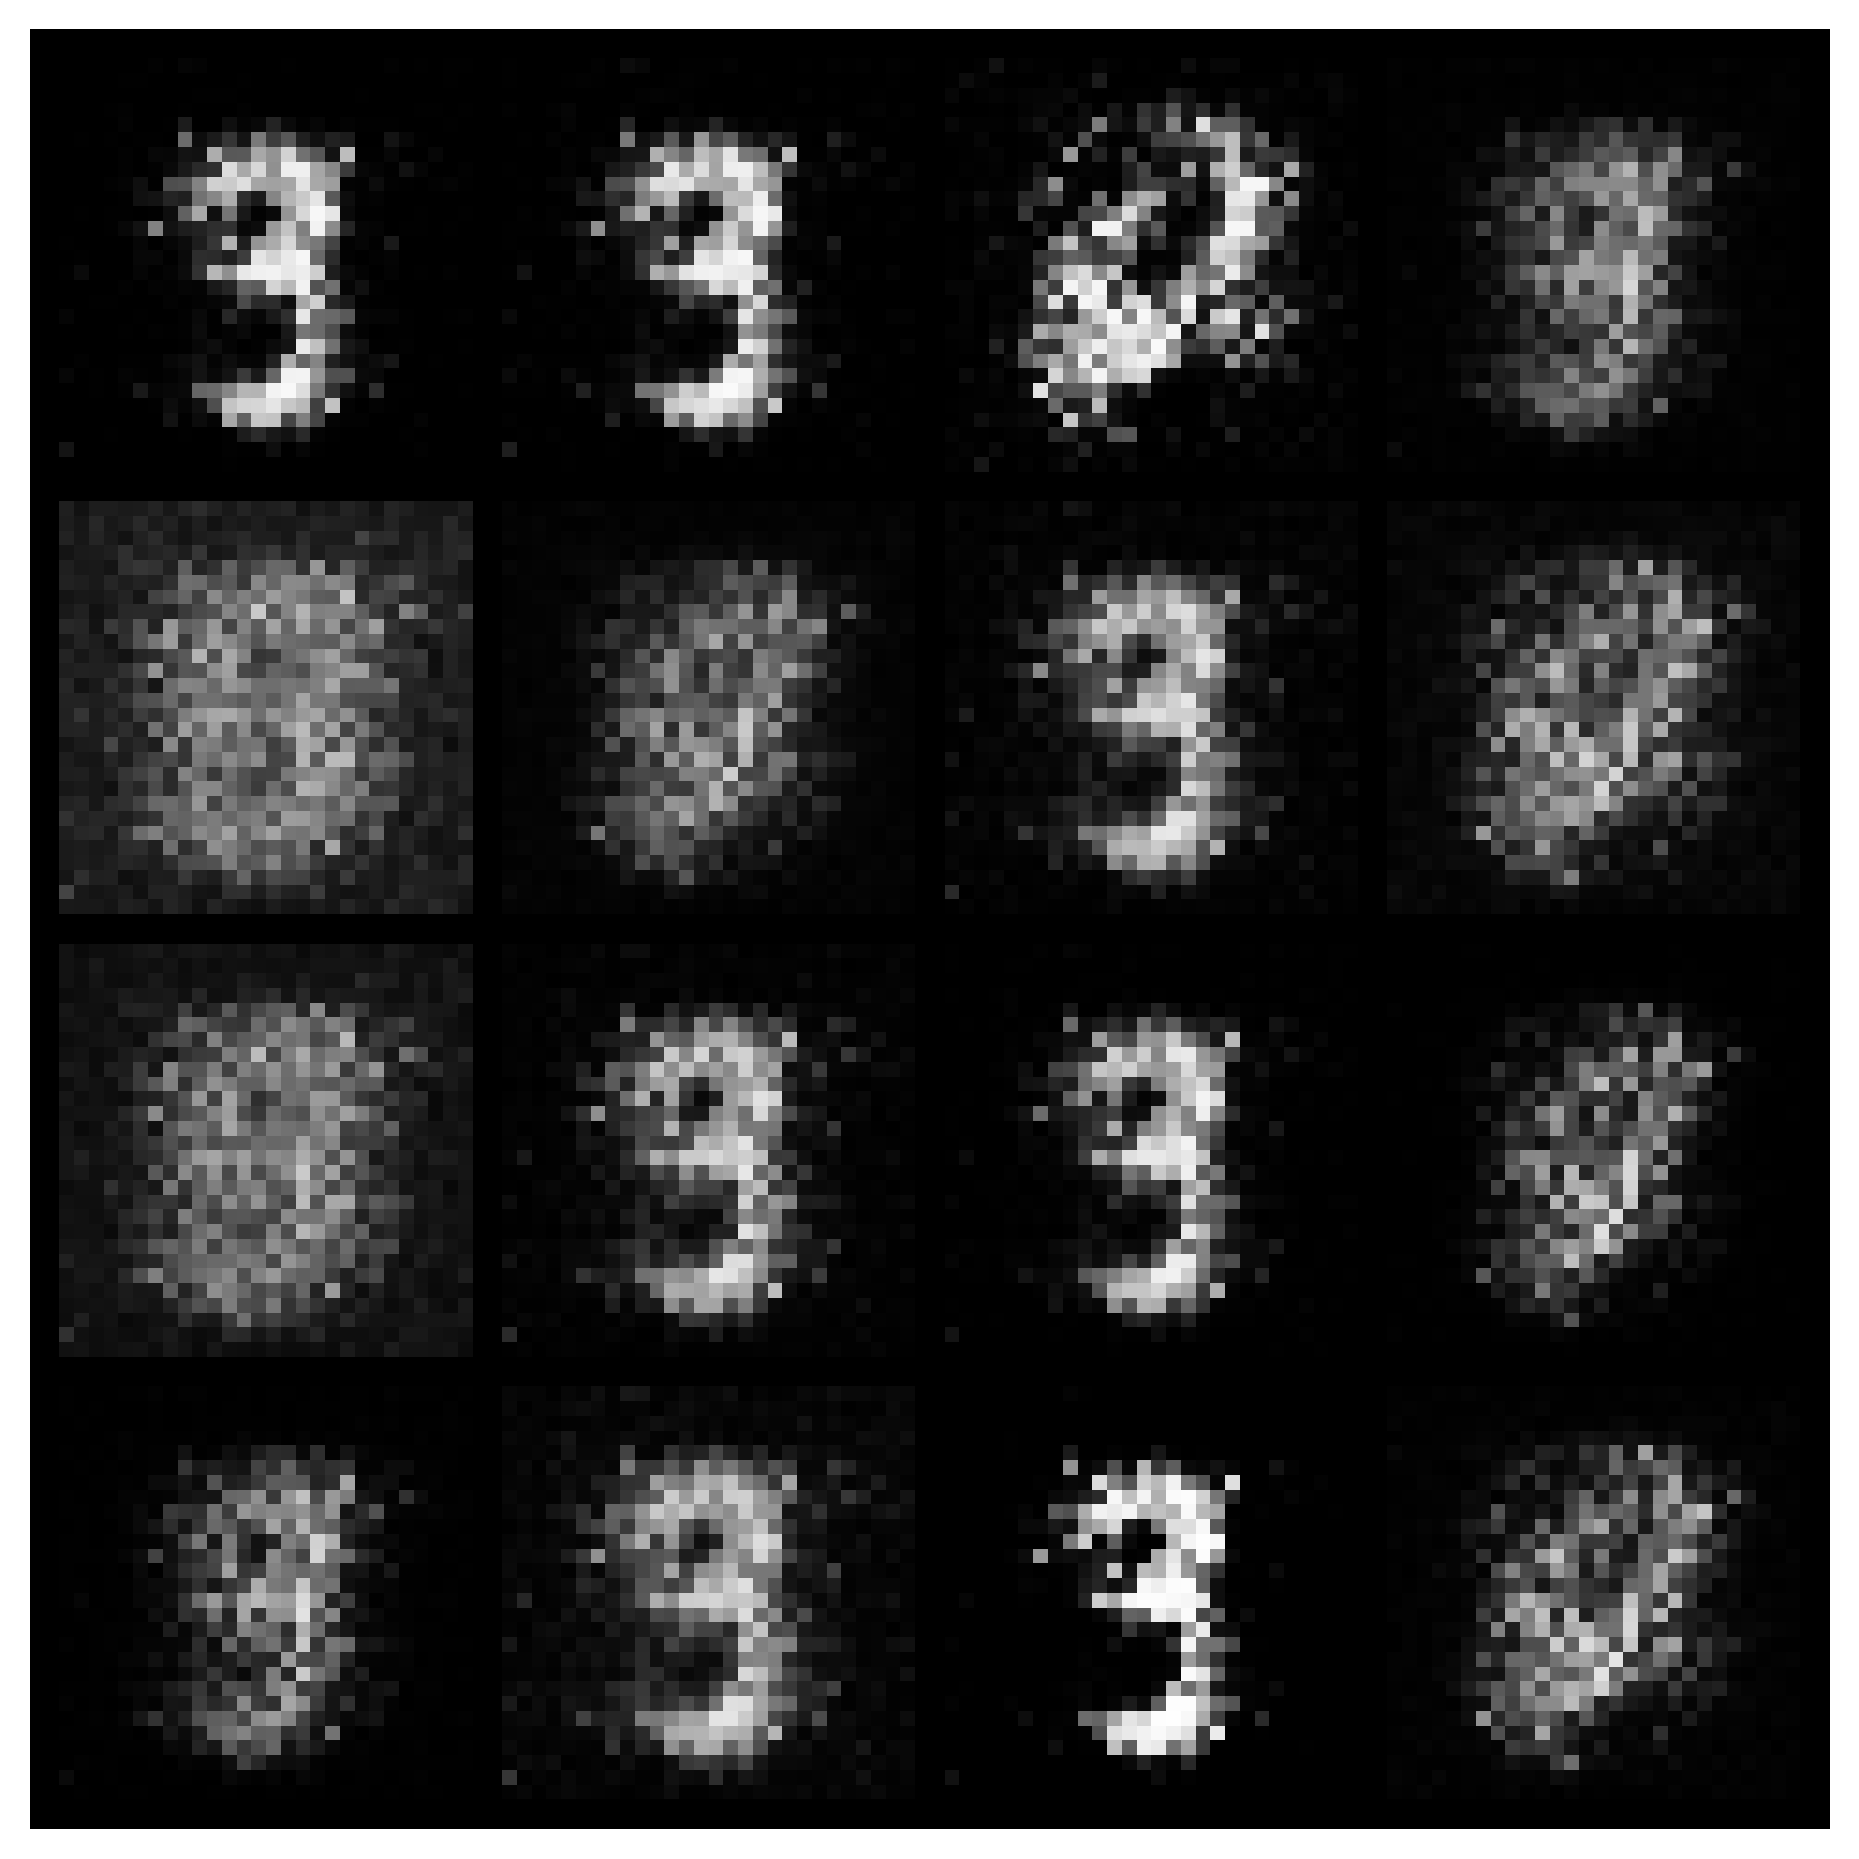

In [6]:
import torch
from torchvision import utils as vutils
import matplotlib.pyplot as plt

# generar y mostrar cuadrado 4x4 con el generador actual
with torch.no_grad():
    G.eval()
    z = torch.randn(16, 100)  # mismo latent_dim que usaste
    samples = G(z)
    imgs = (samples + 1) / 2  # pasar de [-1,1] a [0,1]
    grid = vutils.make_grid(imgs, nrow=4, padding=2)

plt.figure(figsize=(6,6), dpi=300)
plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()



## 🧠 Big Picture: What Your Code Does

You implemented a **vanilla GAN** (Generative Adversarial Network) on **MNIST digits**.

It trains two networks in competition:

1. **Generator (G)** – takes random noise (`z`) and produces fake digits (28×28).
2. **Discriminator (D)** – looks at an image and decides: *real (1)* or *fake (0)*.

They play a **game**:

* D tries to get better at detecting fakes.
* G tries to get better at fooling D.
* Both update alternately, improving each other.

---

## ⚙️ Step-by-Step Explanation

### 1. **Data Preparation**

You loaded MNIST and normalized it to ([-1, 1]), so the generator’s `Tanh()` output matches the same scale.

Each batch:

* `real` → real MNIST images.
* `z` → random noise vectors (size 100).
* `fake = G(z)` → generated (synthetic) images.

---

### 2. **Training Loop**

#### 🧩 A. Discriminator step

You train D to:

* Output **1** for real images (`D(real)`).
* Output **0** for fake ones (`D(fake.detach())`).

Loss for D:
[
L_D = -[ \log(D(x)) + \log(1 - D(G(z))) ]
]
So D wants **high** `D(real)` and **low** `D(fake)`.

---

#### 🧩 B. Generator step

You train G to **fool D**:

* The generator’s loss is:
  [
  L_G = - \log(D(G(z)))
  ]
  That means G tries to make D output **1** for fake images — i.e., D thinks they’re real.

---

### 3. **Loss Values**

From your log:

| Epoch | Loss_D | Loss_G  | Interpretation                                                    |
| ----- | ------ | ------- | ----------------------------------------------------------------- |
| 1     | 0.049  | 4.386   | D easily wins (fake images are garbage).                          |
| 3–6   | ~1.0   | 1.5–3.0 | Both start improving; some balance.                               |
| 8–10  | ~0.8   | ~2.0    | Generator producing semi-realistic shapes; D not perfect anymore. |

The alternating values show the *adversarial tug-of-war*:

* If `Loss_D → 0`, D dominates (G’s output is easily spotted).
* If `Loss_G` decreases, G is improving (fakes look more real).
* Ideal = Both losses fluctuate but stay finite.

---

### 4. **Generated Images**

That final grid (blurry 3s) is **G(z)** after 10 epochs.

What you’re seeing:

* The generator has *learned some structure* of digits — especially the shape of “3”.
* Still blurry = training is too short, architecture is small, and resolution low.
* With more epochs (50–100) or a convolutional GAN (DCGAN), you’ll get crisp, realistic digits.

---

## 🧩 Conceptually — What It Shows

You’ve just trained a system that:

* **Starts from pure noise** (no labels, no hints).
* **Learns by competition** — the only feedback is “can D tell it’s fake?”
* **Produces new samples** that look like the training data — not memorized, but *generated*.

That’s the foundation of all modern generative AI: diffusion models, style transfer, deepfakes — all descend from this GAN framework.



---

### 🧩 Roles of G and D

| Network               | Name                      | Purpose                                        | What it learns                                    |
| --------------------- | ------------------------- | ---------------------------------------------- | ------------------------------------------------- |
| **G (Generator)**     | the *artist*              | Takes random noise → produces fake samples     | How to make data that looks real                  |
| **D (Discriminator)** | the *critic / classifier* | Takes an image → predicts real (1) or fake (0) | How to distinguish real data from generated fakes |

So yes:

* **G is the actual generator** — it’s creating new data.
* **D acts like a binary classifier** — but instead of classifying digits (0–9), it classifies *real vs fake*.

---

### 🔁 How they train simultaneously

1. **D-step**

   * D sees both **real data** from the dataset and **fake data** from G.
   * D learns to **output 1 for real, 0 for fake.**

2. **G-step**

   * G generates new fakes (`G(z)`).
   * D tries to classify them → G gets feedback.
   * G updates its weights to **fool D** (make D output 1 for its fakes).

3. **Repeat**

   * You alternate updates: first D, then G — both improving together.

---

### 🎮 Intuitive analogy

It’s like a **counterfeiter vs. a detective**:

* The **counterfeiter (G)** makes fake money.
* The **detective (D)** learns to spot counterfeits.
* Every time the detective improves, the counterfeiter must get better too.
* The “game” keeps pushing both to improve — until the fake money looks real enough that even the detective can’t tell.

---

So yes — both models are trained **simultaneously but adversarially**:

* D improves as a **classifier** (real vs fake).
* G improves as a **generator** (fooling D).

And that dynamic tension is what makes GANs capable of producing **realistic-looking data** from pure noise.


1) Core (10 min)
Task: Change latent dim from 100 → 32 and observe sample quality.

Epoch 1: Loss_D=0.209, Loss_G=3.195
Epoch 2: Loss_D=0.555, Loss_G=3.152
Epoch 3: Loss_D=1.223, Loss_G=2.800
Epoch 4: Loss_D=0.814, Loss_G=1.538
Epoch 5: Loss_D=0.659, Loss_G=1.946
Epoch 6: Loss_D=0.348, Loss_G=5.361
Epoch 7: Loss_D=0.562, Loss_G=2.902
Epoch 8: Loss_D=0.826, Loss_G=2.480
Epoch 9: Loss_D=0.596, Loss_G=2.857
Epoch 10: Loss_D=0.263, Loss_G=2.903


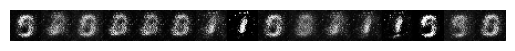

In [5]:
latent_dim = 32

# Generator & Discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G, D = Generator(), Discriminator()
loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

losses_D = []
losses_G = []

# Training loop
for epoch in range(10):
    for real, _ in loader:
        bsz = real.size(0)
        real = real
        z = torch.randn(bsz, latent_dim)
        fake = G(z)

        # --- Train Discriminator ---
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_D = -(torch.log(D_real + 1e-8).mean() + torch.log(1 - D_fake + 1e-8).mean())
        losses_D.append(loss_D.item())
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train Generator ---
        D_fake = D(fake)
        loss_G = -torch.log(D_fake + 1e-8).mean()
        losses_G.append(loss_G.item())
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    print(f"Epoch {epoch+1}: Loss_D={loss_D:.3f}, Loss_G={loss_G:.3f}")

# Generate samples
with torch.no_grad():
    z = torch.randn(16, latent_dim)
    gen = (G(z) + 1) / 2
    grid = torch.cat([g.squeeze() for g in gen], dim=1)
plt.imshow(grid, cmap="gray"); plt.axis("off"); plt.show()

2) Practice (15 min)
Task: Plot loss curves for D and G across epochs.

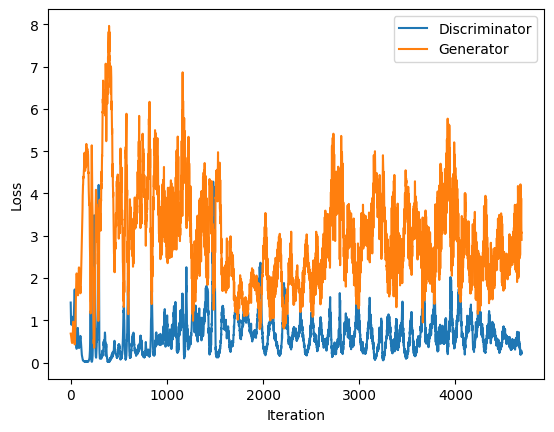

In [6]:
plt.plot(losses_D, label="Discriminator")
plt.plot(losses_G, label="Generator")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


3) Stretch (optional, 15 min)
Task: Add label noise (0.9 for real labels).

Epoch 1: Loss_D=0.531, Loss_G=3.269
Epoch 2: Loss_D=0.740, Loss_G=2.269
Epoch 3: Loss_D=0.547, Loss_G=3.114
Epoch 4: Loss_D=0.672, Loss_G=2.206
Epoch 5: Loss_D=0.581, Loss_G=2.773
Epoch 6: Loss_D=1.053, Loss_G=3.175
Epoch 7: Loss_D=1.012, Loss_G=7.157
Epoch 8: Loss_D=0.756, Loss_G=2.817
Epoch 9: Loss_D=0.714, Loss_G=3.049
Epoch 10: Loss_D=0.701, Loss_G=2.056


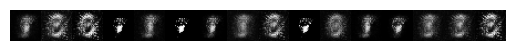

In [7]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
torch.manual_seed(42)

# Data (MNIST 0–1 normalized then scaled to [-1,1] to match Tanh)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# Generator & Discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G, D = Generator(), Discriminator()

# CHANGE: use BCE loss with labels so we can do label smoothing
loss_fn = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Training loop
for epoch in range(10):
    for real, _ in loader:
        bsz = real.size(0)

        # Noise
        z = torch.randn(bsz, 100)
        fake = G(z)

        # -------- Train Discriminator --------
        # CHANGE: label smoothing for real labels (0.9 instead of 1.0)
        real_labels = torch.full((bsz, 1), 0.9)
        fake_labels = torch.zeros((bsz, 1))

        opt_D.zero_grad()
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_real = loss_fn(D_real, real_labels)
        loss_fake = loss_fn(D_fake, fake_labels)
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # -------- Train Generator --------
        # G wants D(fake) -> 1
        opt_G.zero_grad()
        z = torch.randn(bsz, 100)
        fake = G(z)
        D_fake = D(fake)
        loss_G = loss_fn(D_fake, torch.ones((bsz, 1)))
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}: Loss_D={loss_D.item():.3f}, Loss_G={loss_G.item():.3f}")

# Generate samples
with torch.no_grad():
    z = torch.randn(16, 100)
    gen = (G(z) + 1) / 2
    grid = torch.cat([g.squeeze() for g in gen], dim=1)
plt.imshow(grid, cmap="gray"); plt.axis("off"); plt.show()


Mini-Challenge (≤ 40 min)

Goal: Train GAN for 20 epochs → generate digit grid.
Acceptance Criteria:

Loss_D and Loss_G plotted.

At least 8×8 sample grid saved (gan_samples.png).

Brief note (≤3 lines) explaining which epoch produced best images and why (usually mid-training).

Epoch 1/20 | Loss_D=0.531, Loss_G=3.269
Epoch 2/20 | Loss_D=0.740, Loss_G=2.269
Epoch 3/20 | Loss_D=0.547, Loss_G=3.114
Epoch 4/20 | Loss_D=0.672, Loss_G=2.206
Epoch 5/20 | Loss_D=0.581, Loss_G=2.773
Epoch 6/20 | Loss_D=1.076, Loss_G=3.434
Epoch 7/20 | Loss_D=0.795, Loss_G=4.218
Epoch 8/20 | Loss_D=1.100, Loss_G=2.398
Epoch 9/20 | Loss_D=0.945, Loss_G=1.852
Epoch 10/20 | Loss_D=0.620, Loss_G=2.767
Epoch 11/20 | Loss_D=0.577, Loss_G=3.656
Epoch 12/20 | Loss_D=0.786, Loss_G=2.706
Epoch 13/20 | Loss_D=0.644, Loss_G=2.859
Epoch 14/20 | Loss_D=0.594, Loss_G=3.189
Epoch 15/20 | Loss_D=0.739, Loss_G=3.471
Epoch 16/20 | Loss_D=0.751, Loss_G=2.529
Epoch 17/20 | Loss_D=0.784, Loss_G=2.723
Epoch 18/20 | Loss_D=0.722, Loss_G=3.171
Epoch 19/20 | Loss_D=0.838, Loss_G=2.223
Epoch 20/20 | Loss_D=0.817, Loss_G=2.454


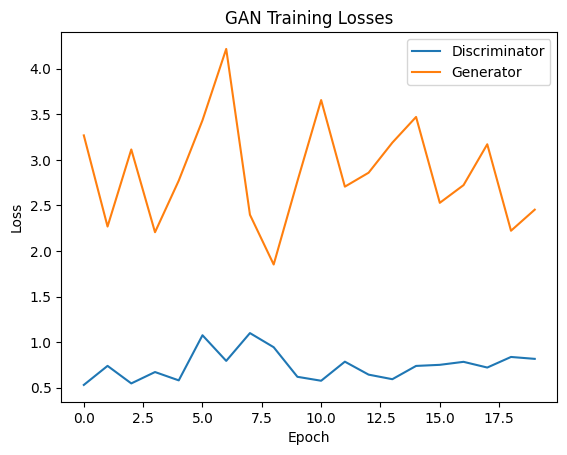

✅ Saved sample grid as gan_samples.png

Note:
Best images usually appear around epoch 10–15 — when D and G are balanced.
Earlier epochs: noisy digits; later epochs: risk of mode collapse (less variety).


In [8]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
from pathlib import Path
torch.manual_seed(42)

# Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# Generator & Discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# Init
G, D = Generator(), Discriminator()
loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Track losses
losses_D, losses_G = [], []
sample_dir = Path("samples"); sample_dir.mkdir(exist_ok=True)

# Training loop (20 epochs)
epochs = 20
for epoch in range(epochs):
    for real, _ in loader:
        bsz = real.size(0)
        z = torch.randn(bsz, 100)
        fake = G(z)

        # --- Train Discriminator ---
        real_labels = torch.full((bsz, 1), 0.9)   # label smoothing
        fake_labels = torch.zeros((bsz, 1))
        D_real, D_fake = D(real), D(fake.detach())

        loss_real = loss_fn(D_real, real_labels)
        loss_fake = loss_fn(D_fake, fake_labels)
        loss_D = loss_real + loss_fake
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train Generator ---
        z = torch.randn(bsz, 100)
        fake = G(z)
        D_fake = D(fake)
        loss_G = loss_fn(D_fake, torch.ones((bsz, 1)))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    # Store epoch losses
    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())

    # Save generated grid every 5 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            z = torch.randn(64, 100)
            gen_imgs = (G(z) + 1) / 2  # back to [0,1]
            utils.save_image(gen_imgs, sample_dir / f"gan_epoch{epoch+1}.png", nrow=8)
    print(f"Epoch {epoch+1}/{epochs} | Loss_D={loss_D.item():.3f}, Loss_G={loss_G.item():.3f}")

# Plot losses
plt.plot(losses_D, label="Discriminator")
plt.plot(losses_G, label="Generator")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("GAN Training Losses")
plt.savefig("gan_losses.png", bbox_inches='tight')
plt.show()

# Save final sample grid
with torch.no_grad():
    z = torch.randn(64, 100)
    gen_imgs = (G(z) + 1) / 2
    utils.save_image(gen_imgs, "gan_samples.png", nrow=8)
print("✅ Saved sample grid as gan_samples.png")

# Brief note
print("\nNote:")
print("Best images usually appear around epoch 10–15 — when D and G are balanced.")
print("Earlier epochs: noisy digits; later epochs: risk of mode collapse (less variety).")


Notes / Key Takeaways

GAN = minimax game → dynamic equilibrium, not true convergence.

Generator learns data distribution through feedback from D.

Balance learning rates and updates for stability.

Use LeakyReLU + BatchNorm to avoid vanishing gradients.

Evaluate visually + with FID or IS later on.

Reflection

What makes GAN training different from standard supervised learning?

Why do loss curves oscillate instead of converging?

1. What makes GAN training different from standard supervised learning?
In supervised learning, the model learns from fixed labels — the target is known and stable.
In GANs, two models (Generator and Discriminator) learn simultaneously and adversarially: the Generator’s goal depends on the Discriminator’s feedback, which keeps changing as both improve.

2. Why do loss curves oscillate instead of converging?
Because GAN training is a dynamic game, not a fixed optimization problem.
As the Discriminator improves, the Generator’s loss rises, and vice versa — creating constant back-and-forth adjustments. The goal is to reach a moving balance (equilibrium), not a single minimum, so losses naturally oscillate.